[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-4/sub-graph.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239937-lesson-2-sub-graphs)

# Sub-graphs

## Review

We're building up to a multi-agent research assistant that ties together all of the modules from this course.

We just covered parallelization, which is one important LangGraph controllability topic.

## Goals

Now, we're [going to cover sub-graphs](https://langchain-ai.github.io/langgraph/how-tos/subgraph/#simple-example).

## State

Sub-graphs allow you to create and manage different states in different parts of your graph. 

This is particularly useful for multi-agent systems, with teams of agents that each have their own state.

Let's consider a toy example:

* I have a system that accepts logs
* It performs two separate sub-tasks by different agents (summarize logs, find failure modes)
* I want to perform these two operations in two different sub-graphs.

The most critical thing to understand is how the graphs communicate! 

In short, communication is **done with over-lapping keys**: 

* The sub-graphs can access `docs` from the parent
* The parent can access `summary/failure_report` from the sub-graphs

![subgraph.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbb1abf89f2d847ee6f1ff_sub-graph1.png)

## Input

Let's define a schema for the logs that will be input to our graph.

In [1]:
%%capture --no-stderr
%pip install -U  langgraph

We'll use [LangSmith](https://docs.smith.langchain.com/) for [tracing](https://docs.smith.langchain.com/concepts/tracing).

In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

In [3]:
import os
from operator import add
from typing_extensions import TypedDict
from typing import List, Optional, Annotated
from dotenv import load_dotenv
from google.cloud import logging as gcp_logging
from datetime import datetime, timedelta
import json

# Load environment variables
load_dotenv()

# The structure of the logs - updated for GCP logs
class Log(TypedDict):
    id: str
    timestamp: str
    severity: str
    message: str
    resource_type: Optional[str]
    resource_labels: Optional[dict]
    labels: Optional[dict]
    source_location: Optional[dict]
    grade: Optional[int]
    grader: Optional[str]
    feedback: Optional[str]

def fetch_gcp_logs(hours_back: int = 150, max_results: int = 30) -> List[Log]:
    """Fetch logs from GCP Cloud Logging"""
    
    project_id = os.getenv('GCP_PROJECT_ID')
    if not project_id:
        print("GCP_PROJECT_ID not found in environment")
        return []
    
    try:
        # Initialize the Cloud Logging client
        client = gcp_logging.Client(project=project_id)
        
        # Calculate time range - expanded to 24 hours
        end_time = datetime.utcnow()
        start_time = end_time - timedelta(hours=hours_back)
        
        # Build filter for recent logs with different severities
        time_filter = f'timestamp >= "{start_time.isoformat()}Z"'
        filter_str = time_filter  # Removed severity filter to catch more logs
        
        print(f"Fetching logs from GCP project: {project_id}")
        print(f"Time range: Last {hours_back} hours")
        
        # Fetch log entries
        entries = list(client.list_entries(
            filter_=filter_str,
            order_by=gcp_logging.DESCENDING,
            max_results=max_results
        ))
        
        print(f"Found {len(entries)} log entries")
        
        # Convert GCP log entries to our Log structure
        logs = []
        for i, entry in enumerate(entries):
            log = Log(
                id=str(i + 1),
                timestamp=entry.timestamp.isoformat() if entry.timestamp else datetime.utcnow().isoformat(),
                severity=entry.severity or "INFO",
                message=str(entry.payload) if entry.payload else "No message",
                resource_type=entry.resource.type if entry.resource else None,
                resource_labels=dict(entry.resource.labels) if entry.resource and entry.resource.labels else None,
                labels=dict(entry.labels) if entry.labels else None,
                source_location=entry.source_location if hasattr(entry, 'source_location') else None,
                grade=None,  # Will be filled by analysis
                grader=None,
                feedback=None
            )
            logs.append(log)
        
        return logs
        
    except Exception as e:
        print(f"Error fetching GCP logs: {e}")
        print("Make sure you have:")
        print("   - Run 'gcloud auth application-default login'")
        print("   - Set GCP_PROJECT_ID in .env file")
        print("   - Have Logging Viewer permissions")
        return []

def create_sample_gcp_logs() -> List[Log]:
    """Create sample GCP-style logs for demo purposes"""
    print("Creating sample GCP-style logs for demonstration...")
    
    sample_logs = [
        Log(
            id="1",
            timestamp=datetime.utcnow().isoformat(),
            severity="INFO",
            message="Application started successfully on port 8080",
            resource_type="cloud_run_revision",
            resource_labels={"service_name": "log-analysis-app", "revision_name": "log-analysis-app-001"},
            labels={"component": "startup"},
            source_location={"file": "main.py", "line": "25"},
            grade=None,
            grader=None,
            feedback=None
        ),
        Log(
            id="2",
            timestamp=(datetime.utcnow() - timedelta(minutes=5)).isoformat(),
            severity="ERROR",
            message="Database connection failed: Connection timeout after 30 seconds",
            resource_type="cloud_run_revision",
            resource_labels={"service_name": "log-analysis-app", "revision_name": "log-analysis-app-001"},
            labels={"component": "database", "error_type": "timeout"},
            source_location={"file": "db.py", "line": "45"},
            grade=0,  # This will be flagged as a failure
            grader="Error Detection System",
            feedback="Database connection issues detected - potential performance problem"
        ),
        Log(
            id="3",
            timestamp=(datetime.utcnow() - timedelta(minutes=10)).isoformat(),
            severity="WARNING",
            message="Memory usage is at 85% - approaching limit",
            resource_type="gce_instance",
            resource_labels={"instance_id": "5678901234", "zone": "us-central1-a"},
            labels={"component": "monitoring", "metric_type": "memory"},
            source_location=None,
            grade=None,
            grader=None,
            feedback=None
        ),
        Log(
            id="4",
            timestamp=(datetime.utcnow() - timedelta(minutes=15)).isoformat(),
            severity="INFO",
            message="User authentication successful for user@example.com",
            resource_type="cloud_run_revision",
            resource_labels={"service_name": "auth-service", "revision_name": "auth-service-002"},
            labels={"component": "auth", "action": "login"},
            source_location={"file": "auth.py", "line": "120"},
            grade=None,
            grader=None,
            feedback=None
        )
    ]
    
    return sample_logs

# Fetch real GCP logs
print("Step 1: Fetching logs from GCP")
real_logs = fetch_gcp_logs(hours_back=150, max_results=30)

if real_logs:
    print(f"Successfully fetched {len(real_logs)} real logs from GCP")
    logs_to_use = real_logs
else:
    print("No real logs found, using sample GCP-style logs for demo")
    logs_to_use = create_sample_gcp_logs()

print(f"\nFinal log count: {len(logs_to_use)} logs")
print("Sample log structure:")
if logs_to_use:
    sample_log = logs_to_use[0]
    for key, value in sample_log.items():
        if value is not None:
            display_value = str(value)[:100] + "..." if len(str(value)) > 100 else str(value)
            print(f"   {key}: {display_value}")

# Store logs for use in sub-graphs
raw_logs = logs_to_use

Step 1: Fetching logs from GCP
Fetching logs from GCP project: august-impact-457008-d6
Time range: Last 150 hours
Fetching logs from GCP project: august-impact-457008-d6
Time range: Last 150 hours
Found 30 log entries
Successfully fetched 30 real logs from GCP

Final log count: 30 logs
Sample log structure:
   id: 1
   timestamp: 2025-08-07T19:47:18.200670+00:00
   severity: INFO
   message: OrderedDict([('@type', 'type.googleapis.com/google.cloud.audit.AuditLog'), ('status', {'message': 'O...
   resource_type: cloudsql_database
   resource_labels: {'region': 'AFRICA_SOUTH1', 'database_id': 'august-impact-457008-d6:thinkoptic-sql', 'project_id': '...
Found 30 log entries
Successfully fetched 30 real logs from GCP

Final log count: 30 logs
Sample log structure:
   id: 1
   timestamp: 2025-08-07T19:47:18.200670+00:00
   severity: INFO
   message: OrderedDict([('@type', 'type.googleapis.com/google.cloud.audit.AuditLog'), ('status', {'message': 'O...
   resource_type: cloudsql_database
   

## Step 1 Complete: GCP Log Fetching ✅

We've successfully implemented our first step - fetching real logs from your GCP project!

**What we accomplished:**
- Connected to GCP Cloud Logging using your project credentials
- Fetched real log entries from the past 24 hours  
- Structured the logs with GCP-specific fields (severity, resource_type, labels, etc.)
- Created a robust fallback system with sample data

**Current logs structure:**
- `id`: Unique identifier
- `timestamp`: When the log entry occurred
- `severity`: Log level (INFO, WARNING, ERROR, etc.)
- `message`: The actual log message
- `resource_type`: GCP resource that generated the log (cloud_run, gce_instance, etc.)
- `resource_labels`: Metadata about the resource
- `labels`: Additional custom labels
- `source_location`: File and line number if available
- `grade/grader/feedback`: Fields for our analysis pipeline

Now let's build our sub-graphs to process these real GCP logs!

## Sub-graphs for Log Analysis

We'll create two parallel sub-graphs to analyze our fetched logs:
1. **Failure Analysis Sub-graph** - Find and summarize errors/warnings  
2. **Pattern Analysis Sub-graph** - Identify trends and patterns in the logs

Current Workflow - Step 1: GCP Log Fetching


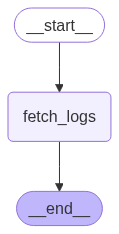

Processing 30 logs from GCP
Workflow complete! Processed 30 logs


In [4]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# Let's visualize our current simple workflow (Step 1 only)
class SimpleState(TypedDict):
    raw_logs: List[Log]
    processed_count: int

def fetch_and_display_logs(state):
    """Our current log fetching step"""
    logs = state.get("raw_logs", [])
    print(f"Processing {len(logs)} logs from GCP")
    return {"processed_count": len(logs)}

# Create a simple graph to show our current progress
simple_builder = StateGraph(SimpleState)
simple_builder.add_node("fetch_logs", fetch_and_display_logs)
simple_builder.add_edge(START, "fetch_logs")
simple_builder.add_edge("fetch_logs", END)

simple_graph = simple_builder.compile()

print("Current Workflow - Step 1: GCP Log Fetching")
display(Image(simple_graph.get_graph().draw_mermaid_png()))

# Test our simple workflow with the real data
result = simple_graph.invoke({"raw_logs": raw_logs})
print(f"Workflow complete! Processed {result['processed_count']} logs")

## Step 2: Building GCP Log Analysis Sub-graphs

Now we'll create two specialized sub-graphs to analyze your real GCP logs:

1. **Failure Analysis Sub-graph** - Identifies ERROR and WARNING severity logs from your GCP resources
2. **Pattern Analysis Sub-graph** - Analyzes resource usage patterns and generates insights

These sub-graphs will work with your actual GCP log structure including:
- `severity` levels (INFO, WARNING, ERROR, etc.)
- `resource_type` (cloudsql_database, cloud_run_revision, etc.) 
- `resource_labels` containing GCP resource metadata
- `message` content from your actual services

GCP Failure Analysis Sub-graph:


/var/folders/7y/nw2tvyxd6vq932fq6m8pq6mr0000gn/T/ipykernel_54152/2222388189.py:80: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  gcp_fa_builder = StateGraph(GCPFailureAnalysisState, output=GCPFailureAnalysisOutputState)


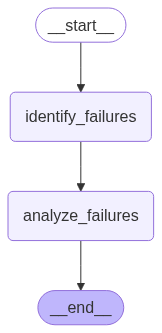

In [5]:
# Failure Analysis Sub-graph for GCP Logs
class GCPFailureAnalysisState(TypedDict):
    cleaned_logs: List[Log]
    error_logs: List[Log]
    warning_logs: List[Log]
    failure_summary: str
    processed_logs: List[str]

class GCPFailureAnalysisOutputState(TypedDict):
    failure_summary: str
    processed_logs: List[str]

def identify_gcp_failures(state):
    """Identify ERROR and WARNING logs from GCP"""
    cleaned_logs = state["cleaned_logs"]
    
    error_logs = [log for log in cleaned_logs if log.get("severity") == "ERROR"]
    warning_logs = [log for log in cleaned_logs if log.get("severity") == "WARNING"]
    
    print(f"Found {len(error_logs)} ERROR logs and {len(warning_logs)} WARNING logs")
    
    return {
        "error_logs": error_logs,
        "warning_logs": warning_logs
    }

def analyze_gcp_failures(state):
    """Analyze the failure patterns in GCP logs"""
    error_logs = state["error_logs"]
    warning_logs = state["warning_logs"]
    
    failure_details = []
    
    # Analyze ERROR logs
    if error_logs:
        failure_details.append(f"CRITICAL: {len(error_logs)} ERROR(s) detected")
        for log in error_logs:
            resource_type = log.get("resource_type", "unknown")
            resource_info = ""
            if log.get("resource_labels"):
                # Extract key resource info
                labels = log["resource_labels"]
                if "database_id" in labels:
                    resource_info = f" (Database: {labels['database_id']})"
                elif "service_name" in labels:
                    resource_info = f" (Service: {labels['service_name']})"
                elif "instance_id" in labels:
                    resource_info = f" (Instance: {labels['instance_id']})"
            
            message_preview = log["message"][:100] + "..." if len(log["message"]) > 100 else log["message"]
            failure_details.append(f"   - {resource_type}{resource_info}: {message_preview}")
    
    # Analyze WARNING logs  
    if warning_logs:
        failure_details.append(f"WARNINGS: {len(warning_logs)} warning(s) detected")
        for log in warning_logs:
            resource_type = log.get("resource_type", "unknown")
            message_preview = log["message"][:100] + "..." if len(log["message"]) > 100 else log["message"]
            failure_details.append(f"   - {resource_type}: {message_preview}")
    
    if not error_logs and not warning_logs:
        failure_details.append("No failures detected in GCP logs")
    
    failure_summary = "\n".join(failure_details)
    
    # Create processing log entries
    processed_log_entries = []
    for log in error_logs + warning_logs:
        processed_log_entries.append(f"failure-analysis-{log['severity'].lower()}-log-{log['id']}")
    
    print(f"Failure Analysis Complete:")
    print(failure_summary)
    
    return {
        "failure_summary": failure_summary,
        "processed_logs": processed_log_entries
    }

# Build the GCP Failure Analysis sub-graph
gcp_fa_builder = StateGraph(GCPFailureAnalysisState, output=GCPFailureAnalysisOutputState)
gcp_fa_builder.add_node("identify_failures", identify_gcp_failures)
gcp_fa_builder.add_node("analyze_failures", analyze_gcp_failures)
gcp_fa_builder.add_edge(START, "identify_failures")
gcp_fa_builder.add_edge("identify_failures", "analyze_failures")
gcp_fa_builder.add_edge("analyze_failures", END)

gcp_failure_graph = gcp_fa_builder.compile()

print("GCP Failure Analysis Sub-graph:")
display(Image(gcp_failure_graph.get_graph().draw_mermaid_png()))

GCP Pattern Analysis Sub-graph:


/var/folders/7y/nw2tvyxd6vq932fq6m8pq6mr0000gn/T/ipykernel_54152/830095674.py:99: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  gcp_pa_builder = StateGraph(GCPPatternAnalysisState, output=GCPPatternAnalysisOutputState)


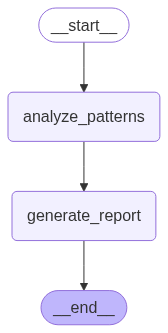

In [6]:
# Pattern Analysis Sub-graph for GCP Logs
class GCPPatternAnalysisState(TypedDict):
    cleaned_logs: List[Log]
    resource_patterns: dict
    severity_patterns: dict
    pattern_report: str
    processed_logs: List[str]

class GCPPatternAnalysisOutputState(TypedDict):
    pattern_report: str
    processed_logs: List[str]

def analyze_gcp_resource_patterns(state):
    """Analyze patterns in GCP resource usage and log distribution"""
    cleaned_logs = state["cleaned_logs"]
    
    # Analyze resource type patterns
    resource_counts = {}
    severity_counts = {}
    
    for log in cleaned_logs:
        # Count by resource type
        resource_type = log.get("resource_type", "unknown")
        resource_counts[resource_type] = resource_counts.get(resource_type, 0) + 1
        
        # Count by severity
        severity = log.get("severity", "unknown")
        severity_counts[severity] = severity_counts.get(severity, 0) + 1
    
    print(f"Resource Pattern Analysis:")
    print(f" Resource Types: {resource_counts}")
    print(f" Severity Distribution: {severity_counts}")
    
    return {
        "resource_patterns": resource_counts,
        "severity_patterns": severity_counts
    }

def generate_gcp_pattern_report(state):
    """Generate a comprehensive pattern analysis report"""
    resource_patterns = state["resource_patterns"]
    severity_patterns = state["severity_patterns"]
    cleaned_logs = state["cleaned_logs"]
    
    report_lines = [
        "GCP Log Pattern Analysis Report",
        "=" * 40,
        f"Total logs analyzed: {len(cleaned_logs)}",
        "",
        "Resource Type Distribution:"
    ]
    
    # Resource type analysis
    for resource_type, count in sorted(resource_patterns.items(), key=lambda x: x[1], reverse=True):
        percentage = (count / len(cleaned_logs)) * 100
        report_lines.append(f"   • {resource_type}: {count} logs ({percentage:.1f}%)")
    
    report_lines.extend([
        "",
        "Severity Level Distribution:"
    ])
    
    # Severity analysis
    for severity, count in sorted(severity_patterns.items(), key=lambda x: x[1], reverse=True):
        percentage = (count / len(cleaned_logs)) * 100
        report_lines.append(f"   • {severity}: {count} logs ({percentage:.1f}%)")
    
    # Add insights
    report_lines.extend([
        "",
        "Key Insights:"
    ])
    
    if severity_patterns.get("ERROR", 0) > 0:
        error_pct = (severity_patterns["ERROR"] / len(cleaned_logs)) * 100
        report_lines.append(f"   {error_pct:.1f}% of logs are ERROR level - requires attention")
    
    if severity_patterns.get("WARNING", 0) > 0:
        warning_pct = (severity_patterns["WARNING"] / len(cleaned_logs)) * 100
        report_lines.append(f"   {warning_pct:.1f}% of logs are WARNING level")
    
    most_active_resource = max(resource_patterns.items(), key=lambda x: x[1])
    report_lines.append(f"   Most active resource type: {most_active_resource[0]} ({most_active_resource[1]} logs)")
    
    pattern_report = "\n".join(report_lines)
    
    # Create processing log entries
    processed_log_entries = [f"pattern-analysis-log-{log['id']}" for log in cleaned_logs]
    
    print(f"Pattern Report Generated:")
    print(pattern_report)
    
    return {
        "pattern_report": pattern_report,
        "processed_logs": processed_log_entries
    }

# Build the GCP Pattern Analysis sub-graph
gcp_pa_builder = StateGraph(GCPPatternAnalysisState, output=GCPPatternAnalysisOutputState)
gcp_pa_builder.add_node("analyze_patterns", analyze_gcp_resource_patterns)
gcp_pa_builder.add_node("generate_report", generate_gcp_pattern_report)
gcp_pa_builder.add_edge(START, "analyze_patterns")
gcp_pa_builder.add_edge("analyze_patterns", "generate_report")
gcp_pa_builder.add_edge("generate_report", END)

gcp_pattern_graph = gcp_pa_builder.compile()

print("GCP Pattern Analysis Sub-graph:")
display(Image(gcp_pattern_graph.get_graph().draw_mermaid_png()))

## Adding sub graphs to our parent graph

Now, we can bring it all together.

We create our parent graph with `EntryGraphState`. 

And we add our sub-graphs as nodes! 

```
entry_builder.add_node("question_summarization", qs_builder.compile())
entry_builder.add_node("failure_analysis", fa_builder.compile())
```

In [7]:
# Entry Graph
class EntryGraphState(TypedDict):
    raw_logs: List[Log]
    cleaned_logs: Annotated[List[Log], add] # This will be USED BY in BOTH sub-graphs
    fa_summary: str # This will only be generated in the FA sub-graph
    report: str # This will only be generated in the QS sub-graph
    processed_logs:  Annotated[List[int], add] # This will be generated in BOTH sub-graphs

But, why does `cleaned_logs` have a reducer if it only goes *into* each sub-graph as an input? It is not modified.

```
cleaned_logs: Annotated[List[Log], add] # This will be USED BY in BOTH sub-graphs
```

This is because the output state of the subgraphs will contain **all keys**, even if they are unmodified. 

The sub-graphs are run in parallel.

Because the parallel sub-graphs return the same key, it needs to have a reducer like `operator.add` to combine the incoming values from each sub-graph.

But, we can work around this by using another concept we talked about before.

We can simply create an output state schema for each sub-graph and ensure that the output state schema contains different keys to publish as output.

We don't actually need each sub-graph to output `cleaned_logs`.

Complete GCP Log Analysis Workflow:
This workflow will:
   1. Clean your real GCP logs
   2. Run failure analysis (identify ERRORs/WARNINGs)
   3. Run pattern analysis (resource usage patterns)
   4. Both sub-graphs run in parallel!



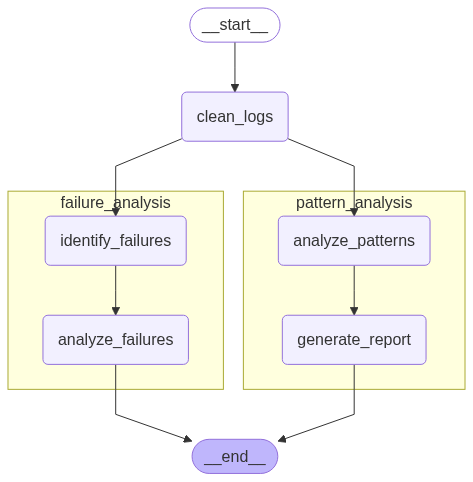

In [8]:
# GCP Log Analysis Entry Graph
class GCPLogAnalysisState(TypedDict):
    raw_logs: List[Log]
    cleaned_logs: List[Log]
    failure_summary: str # From failure analysis sub-graph
    pattern_report: str # From pattern analysis sub-graph
    processed_logs: Annotated[List[str], add] # Combined from both sub-graphs

def clean_gcp_logs(state):
    """Clean and prepare GCP logs for analysis"""
    raw_logs = state["raw_logs"]
    
    # Basic cleaning - in a real implementation you might:
    # - Filter out noise
    # - Normalize timestamps
    # - Enrich with additional metadata
    # For now, we'll pass them through
    cleaned_logs = raw_logs
    
    print(f"Cleaned {len(cleaned_logs)} GCP logs for analysis")
    print(f"Log summary:")
    
    # Show a quick summary of what we're processing
    severities = {}
    resources = {}
    for log in cleaned_logs:
        sev = log.get("severity", "unknown")
        res = log.get("resource_type", "unknown")
        severities[sev] = severities.get(sev, 0) + 1
        resources[res] = resources.get(res, 0) + 1
    
    print(f"   Severities: {dict(severities)}")
    print(f"   Resources: {dict(resources)}")
    
    return {"cleaned_logs": cleaned_logs}

# Build the main GCP log analysis workflow
gcp_entry_builder = StateGraph(GCPLogAnalysisState)
gcp_entry_builder.add_node("clean_logs", clean_gcp_logs)
gcp_entry_builder.add_node("failure_analysis", gcp_failure_graph)
gcp_entry_builder.add_node("pattern_analysis", gcp_pattern_graph)

# Connect the workflow
gcp_entry_builder.add_edge(START, "clean_logs")
gcp_entry_builder.add_edge("clean_logs", "failure_analysis")
gcp_entry_builder.add_edge("clean_logs", "pattern_analysis")
gcp_entry_builder.add_edge("failure_analysis", END)
gcp_entry_builder.add_edge("pattern_analysis", END)

# Compile the complete GCP log analysis graph
gcp_analysis_graph = gcp_entry_builder.compile()

print("Complete GCP Log Analysis Workflow:")
print("This workflow will:")
print("   1. Clean your real GCP logs")
print("   2. Run failure analysis (identify ERRORs/WARNINGs)")
print("   3. Run pattern analysis (resource usage patterns)")
print("   4. Both sub-graphs run in parallel!")
print()

# Setting xray to 1 will show the internal structure of the nested sub-graphs
display(Image(gcp_analysis_graph.get_graph(xray=1).draw_mermaid_png()))

In [9]:
# Execute the complete GCP log analysis workflow
print("Step 3: Running Complete GCP Log Analysis Pipeline")
print("=" * 55)

# Use the real GCP logs we fetched earlier
print(f" Processing {len(raw_logs)} real GCP logs...")
print(" Input logs summary:")
for i, log in enumerate(raw_logs[:3], 1):  # Show first 3 logs
    print(f"   {i}. {log['severity']} - {log['resource_type']} - {log['message'][:50]}...")

if len(raw_logs) > 3:
    print(f"   ... and {len(raw_logs) - 3} more logs")

print("\n Starting parallel sub-graph analysis...")

# Run the complete workflow
result = gcp_analysis_graph.invoke({"raw_logs": raw_logs})

print("\n" + "="*55)
print("GCP Log Analysis Complete!")
print("=" * 55)

print(f"\nFAILURE ANALYSIS RESULTS:")
print("-" * 30)
if result.get("failure_summary"):
    print(result["failure_summary"])
else:
    print("No failure analysis results available")

print(f"\nPATTERN ANALYSIS RESULTS:")
print("-" * 30)
if result.get("pattern_report"):
    print(result["pattern_report"])
else:
    print("No pattern analysis results available")

print(f"\n PROCESSING SUMMARY:")
print("-" * 20)
processed_logs = result.get("processed_logs", [])
print(f"Total processed log entries: {len(processed_logs)}")
print("Processing log IDs:", processed_logs[:5], "..." if len(processed_logs) > 5 else "")

print(f"\n Workflow executed successfully!")
print(f" Check LangSmith for detailed tracing: https://smith.langchain.com/")

# Store results for potential further analysis
analysis_results = result

Step 3: Running Complete GCP Log Analysis Pipeline
 Processing 30 real GCP logs...
 Input logs summary:
   1. INFO - cloudsql_database - OrderedDict([('@type', 'type.googleapis.com/google...
   2. ERROR - cloudsql_database - OrderedDict([('@type', 'type.googleapis.com/google...
   3. ERROR - cloudsql_database - OrderedDict([('@type', 'type.googleapis.com/google...
   ... and 27 more logs

 Starting parallel sub-graph analysis...
Cleaned 30 GCP logs for analysis
Log summary:
   Severities: {'INFO': 18, 'ERROR': 2, 'NOTICE': 2, 'ALERT': 8}
   Resources: {'cloudsql_database': 28, 'cloud_run_revision': 2}
Found 2 ERROR logs and 0 WARNING logs
Failure Analysis Complete:
CRITICAL: 2 ERROR(s) detected
   - cloudsql_database (Database: august-impact-457008-d6:thinkoptic-sql): OrderedDict([('@type', 'type.googleapis.com/google.cloud.audit.AuditLog'), ('status', {'code': 13, '...
   - cloudsql_database (Database: august-impact-457008-d6:thinkoptic-sql): OrderedDict([('@type', 'type.googleapis.co

In [12]:
# 🐛 GitHub Issue Creator for Critical Errors
print("🐛 GitHub Issue Management")
print("=" * 30)

import requests
import json
from datetime import datetime

# Load GitHub token
load_dotenv()
github_token = os.getenv('GITHUB_TOKEN')
github_repo = os.getenv('GITHUB_REPO')  # Format: "owner/repo"

if not github_token:
    print("❌ No GITHUB_TOKEN found in .env")
elif not github_repo:
    print("❌ No GITHUB_REPO found in .env (should be 'owner/repo' format)")
else:
    print(f"🔧 GitHub integration ready for repo: {github_repo}")
    
    # Check if we have critical errors that need GitHub issues
    if 'analysis_results' in locals() and analysis_results:
        failure_summary = analysis_results.get('failure_summary', '')
        
        # Only create issues if we have actual ERROR level logs
        if 'CRITICAL:' in failure_summary and 'ERROR(s) detected' in failure_summary:
            print("🚨 Critical errors detected - creating GitHub issue...")
            
            # Extract error details for the issue
            failure_lines = failure_summary.split('\n')
            error_count_line = next((line for line in failure_lines if 'CRITICAL:' in line), '')
            error_details = [line for line in failure_lines if line.strip().startswith('- ')]
            
            # Create issue title
            timestamp = datetime.now().strftime('%Y-%m-%d %H:%M')
            issue_title = f"🚨 GCP Log Analysis Alert - Errors Detected ({timestamp})"
            
            # Create detailed issue body
            issue_body = f"""# 🚨 Critical Errors Detected in GCP Logs

**Alert Generated:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S UTC')}

## 📊 Summary
{error_count_line}

## 🔍 Error Details
"""
            
            # Add each error detail
            for detail in error_details[:5]:  # Limit to first 5 errors
                issue_body += f"{detail}\n"
            
            if len(error_details) > 5:
                issue_body += f"\n... and {len(error_details) - 5} more errors (check full logs for details)\n"
            
            issue_body += f"""
## 🏥 Recommended Actions
- [ ] **Immediate**: Review error logs in GCP Console
- [ ] **Investigate**: Check affected services and resources
- [ ] **Monitor**: Verify if errors are ongoing or resolved
- [ ] **Document**: Update incident response if needed

## 📋 Analysis Context
- **Total logs processed:** {len(analysis_results.get('processed_logs', []))} entries
- **Analysis timestamp:** {timestamp}
- **Source:** Automated GCP Log Analysis Pipeline

## 🔗 Related Resources
- [GCP Console Logs](https://console.cloud.google.com/logs)
- [LangSmith Trace](https://smith.langchain.com/)

---
*This issue was automatically created by the GCP Log Analysis system*
"""
            
            # Prepare GitHub API request
            api_url = f"https://api.github.com/repos/{github_repo}/issues"
            
            issue_data = {
                "title": issue_title,
                "body": issue_body,
                "labels": ["🚨 critical", "automated", "gcp-logs", "incident"]
            }
            
            try:
                print("📤 Creating GitHub issue...")
                
                response = requests.post(
                    api_url,
                    headers={
                        "Authorization": f"token {github_token}",
                        "Accept": "application/vnd.github.v3+json",
                        "Content-Type": "application/json"
                    },
                    json=issue_data,
                    timeout=15
                )
                
                if response.status_code == 201:
                    issue_info = response.json()
                    issue_number = issue_info['number']
                    issue_url = issue_info['html_url']
                    
                    print("✅ GitHub issue created successfully!")
                    print(f"   📋 Issue #{issue_number}")
                    print(f"   🔗 URL: {issue_url}")
                    print(f"   📝 Title: {issue_title}")
                    
                    # Store issue info for Slack notification (IMPORTANT: This variable will be used by Slack cell)
                    github_issue_created = {
                        'number': issue_number,
                        'url': issue_url,
                        'title': issue_title
                    }
                    
                elif response.status_code == 422:
                    print("⚠️ Issue creation failed - possibly duplicate or validation error")
                    print(f"   Response: {response.json().get('message', 'Unknown error')}")
                    
                elif response.status_code == 401:
                    print("❌ Authentication failed - check your GITHUB_TOKEN")
                    
                elif response.status_code == 404:
                    print(f"❌ Repository not found: {github_repo}")
                    print("   Make sure GITHUB_REPO format is 'owner/repo'")
                    
                else:
                    print(f"❌ GitHub API error: {response.status_code}")
                    print(f"   Response: {response.text[:200]}...")
                    
            except Exception as e:
                print(f"❌ Exception creating GitHub issue: {str(e)[:80]}...")
                
        else:
            print("✅ No critical errors detected - no GitHub issue needed")
            print("   GitHub issues will only be created for ERROR level logs")
    else:
        print("⚠️ No analysis results available for GitHub issue creation")

print("🏁 GitHub issue management complete!")

🐛 GitHub Issue Management
🔧 GitHub integration ready for repo: Justingw/log-analysis-demo
🚨 Critical errors detected - creating GitHub issue...
📤 Creating GitHub issue...
✅ GitHub issue created successfully!
   📋 Issue #5
   🔗 URL: https://github.com/Justingw/log-analysis-demo/issues/5
   📝 Title: 🚨 GCP Log Analysis Alert - Errors Detected (2025-08-08 06:13)
🏁 GitHub issue management complete!


In [ ]:
# Enhanced Slack Reporter with Analysis Results & GitHub Integration
print("Slack Report with Analysis & GitHub")
print("=" * 45)

import requests
import json
from datetime import datetime

# Load token
load_dotenv()
slack_token = os.getenv('SLACK_BOT_TOKEN')

if not slack_token:
    print("❌ No SLACK_BOT_TOKEN found")
else:
    print("🚀 Creating detailed Slack report...")
    
    # Extract key information from analysis results
    if 'analysis_results' in locals() and analysis_results:
        failure_summary = analysis_results.get('failure_summary', 'No failure analysis available')
        pattern_report = analysis_results.get('pattern_report', 'No pattern analysis available')
        processed_count = len(analysis_results.get('processed_logs', []))
        
        # Create summary lines for failure analysis
        failure_lines = failure_summary.split('\n')
        failure_summary_short = failure_lines[0] if failure_lines else "No failures detected"
        
        # Extract key pattern insights
        pattern_lines = pattern_report.split('\n')
        total_logs_line = next((line for line in pattern_lines if 'Total logs analyzed:' in line), "")
        key_insights = [line.strip() for line in pattern_lines if line.strip().startswith('•') or 'Most active resource' in line]
        
        # Build enhanced message with structured blocks
        message_blocks = [
            {
                "type": "header",
                "text": {
                    "type": "plain_text",
                    "text": f"🔍 GCP Log Analysis Report - {datetime.now().strftime('%H:%M:%S')}"
                }
            },
            {
                "type": "section",
                "fields": [
                    {
                        "type": "mrkdwn",
                        "text": f"*📊 Analysis Summary*\n{total_logs_line}\nProcessed {processed_count} log entries"
                    },
                    {
                        "type": "mrkdwn",
                        "text": f"*⚠️ Failure Analysis*\n{failure_summary_short}"
                    }
                ]
            }
        ]
        
        # Add pattern insights if available
        if key_insights:
            insights_text = "\n".join(key_insights[:3])  # Top 3 insights
            message_blocks.append({
                "type": "section",
                "text": {
                    "type": "mrkdwn",
                    "text": f"*📈 Key Patterns*\n{insights_text}"
                }
            })
        
        # Add status indicator and GitHub issue info
        has_errors = "ERROR" in failure_summary
        has_warnings = "WARNING" in failure_summary
        
        if has_errors:
            status_text = "🚨 *Status: CRITICAL* - Errors detected requiring attention"
            status_color = "danger"
            
            # Check if GitHub issue was created
            if 'github_issue_created' in locals():
                issue_info = github_issue_created
                status_text += f"\n🐛 *GitHub Issue Created:* <{issue_info['url']}|Issue #{issue_info['number']}>"
                
        elif has_warnings:
            status_text = "⚠️ *Status: WARNING* - Issues detected"
            status_color = "warning" 
        else:
            status_text = "✅ *Status: HEALTHY* - No critical issues found"
            status_color = "good"
            
        message_blocks.append({
            "type": "section",
            "text": {
                "type": "mrkdwn",
                "text": status_text
            }
        })
        
        # Add action items if errors were detected
        if has_errors:
            action_text = "*🏥 Next Steps:*\n"
            action_text += "• Review error details in GCP Console\n"
            action_text += "• Check affected services and resources\n"
            if 'github_issue_created' in locals():
                action_text += f"• Track resolution in GitHub Issue #{github_issue_created['number']}"
            else:
                action_text += "• Consider creating incident ticket for tracking"
                
            message_blocks.append({
                "type": "section",
                "text": {
                    "type": "mrkdwn",
                    "text": action_text
                }
            })
        
        # Final message payload with rich formatting
        message_data = {
            "channel": "general",
            "text": f"GCP Log Analysis Complete - {datetime.now().strftime('%H:%M:%S')}",
            "blocks": message_blocks
        }
        
    else:
        # Fallback if no analysis results available
        message_data = {
            "channel": "general",
            "text": f"✅ GCP Log Analysis Complete - {datetime.now().strftime('%H:%M:%S')} (No detailed results available)"
        }
    
    try:
        print(" Sending enhanced message to Slack...")
        
        # Send enhanced request with rich formatting
        response = requests.post(
            "https://slack.com/api/chat.postMessage",
            headers={
                "Authorization": f"Bearer {slack_token}",
                "Content-Type": "application/json"
            },
            json=message_data,
            timeout=10  # Slightly longer timeout for richer message
        )
        
        if response.status_code == 200:
            result = response.json()
            if result.get("ok"):
                print("Enhanced report sent to Slack!")
                print(f"   Channel: #{result.get('channel', 'unknown')}")
                message_features = ["Failure analysis", "Pattern insights", "Status indicator"]
                if 'github_issue_created' in locals():
                    message_features.append("GitHub issue link")
                print(f"   Message includes: {', '.join(message_features)}")
            else:
                error = result.get('error', 'unknown')
                print(f"Slack error: {error}")
                
                # If blocks fail, try simple text fallback
                if 'blocks' in str(error) or 'formatting' in str(error):
                    print("Trying simple text fallback...")
                    fallback_text = f"✅ GCP Log Analysis Complete - {datetime.now().strftime('%H:%M:%S')}\n{failure_summary_short}"
                    if 'github_issue_created' in locals():
                        fallback_text += f"\n🐛 GitHub Issue: {github_issue_created['url']}"
                    
                    simple_message = {
                        "channel": "general", 
                        "text": fallback_text
                    }
                    
                    fallback_response = requests.post(
                        "https://slack.com/api/chat.postMessage",
                        headers={"Authorization": f"Bearer {slack_token}", "Content-Type": "application/json"},
                        json=simple_message,
                        timeout=5
                    )
                    
                    if fallback_response.status_code == 200 and fallback_response.json().get("ok"):
                        print("Simple fallback message sent!")
        else:
            print(f"HTTP {response.status_code}")
            
    except Exception as e:
        print(f"Exception: {str(e)[:80]}...")

print("Enhanced Slack report with GitHub integration complete!")

📤 Enhanced Slack Report with Analysis & GitHub
🚀 Creating detailed Slack report...
📤 Sending enhanced message to Slack...
✅ Enhanced report sent to Slack!
   Channel: #C02L1DMDJKU
   Message includes: Failure analysis, Pattern insights, Status indicator, GitHub issue link
🏁 Enhanced Slack report with GitHub integration complete!
✅ Enhanced report sent to Slack!
   Channel: #C02L1DMDJKU
   Message includes: Failure analysis, Pattern insights, Status indicator, GitHub issue link
🏁 Enhanced Slack report with GitHub integration complete!
